# Study EC1 -- Results: CMA-ES variant comparison

Loads cached results from `outputs/ec1_full/` (1000 runs: 5 conditions x
100 images x 2 models, 2000 queries each).

All conditions share the Study 7 "tuned except tau=3" carrier config
(`xi_step_scale=0.5, bs_adaptive=True, cmu_scale=1.0, lam_override=None,
tau=3`), differing only in the covariance representation:

```
sep : evolba_vkd(vk_rank=0)  -- sep-CMA-ES (== evolba_tuned, validated bit-for-bit)
vd1 : evolba_vkd(vk_rank=1)  -- VD-CMA   (C = D(I + VV^T)D, V is n x 1)
vd2 : evolba_vkd(vk_rank=2)  -- VkD-CMA, k=2
vd3 : evolba_vkd(vk_rank=3)  -- VkD-CMA, k=3
o11 : evolba_one_plus_one()  -- (1+1)-CMA-ES, structurally different
      generation loop (1 query/gen, elitist, p_succ-based step adaptation)
```

Full CMA-ES and LM-CMA were considered and discarded -- see `CHANGES.md`.

**Question.** Do a handful of extra low-rank covariance directions (VkD,
k=1..3) capture exploitable structure that sep-CMA-ES's diagonal misses?
And how does the radically different (1+1)-CMA-ES compare?


In [1]:
import pandas as pd, numpy as np, pickle
from IPython.display import Image, display

OUT = 'outputs/ec1_full'
df = pd.read_parquet(f'{OUT}/results.parquet')
with open(f'{OUT}/trajectories.pkl', 'rb') as f:
    all_traj = pickle.load(f)
with open(f'{OUT}/v_norms.pkl', 'rb') as f:
    v_norms_store = pickle.load(f)
with open(f'{OUT}/o11_diag.pkl', 'rb') as f:
    o11_diag = pickle.load(f)

ok = df[df.success]
print(f'{len(df)} runs total, {len(ok)} successful ({df.success.mean()*100:.1f}%)')
ok.head()


1000 runs total, 950 successful (95.0%)


,condition,model,image_idx,true_class,success,queries,init_l2,best_l2,final_l2,n_generations,backtracks_total,bs_calls,bs_queries_actual,l2_at_250,l2_at_500,l2_at_750,l2_at_1000,l2_at_1500,l2_at_2000,improvement_ratio
0,sep,standard,0,3,True,2024,3.052553,3.051146,3.051736,3,6,10,245,3.051146,3.051736,3.051736,3.051736,3.051736,3.051736,0.000461
1,sep,standard,1,8,True,2026,4.176711,1.408597,1.408597,30,4,35,910,2.519318,1.791545,1.791458,1.639257,1.429483,1.408661,0.662750
2,sep,standard,2,8,True,2026,2.302839,1.764662,1.764662,8,6,15,387,2.014325,1.764884,1.764662,1.764662,1.764662,1.764662,0.233702
3,sep,standard,3,0,True,2022,0.973804,0.693619,0.693741,8,3,12,271,0.775451,0.693741,0.693741,0.693741,0.693741,0.693741,0.287723
4,sep,standard,4,6,True,2027,12.981510,7.844198,7.844198,32,2,35,910,11.105731,11.024334,10.308995,9.672223,9.379018,7.848479,0.395741


## Summary table

In [2]:
COND_ORDER  = ['sep', 'vd1', 'vd2', 'vd3', 'o11']
MODEL_NAMES = ['standard', 'robust']
VK_RANK     = {'sep': 0, 'vd1': 1, 'vd2': 2, 'vd3': 3}

summary = ok.groupby(['condition','model']).agg(
    n               = ('best_l2', 'count'),
    median_init     = ('init_l2', 'median'),
    median_best     = ('best_l2', 'median'),
    median_final    = ('final_l2', 'median'),
    median_IR       = ('improvement_ratio', 'median'),
    median_gen      = ('n_generations', 'median'),
    median_queries  = ('queries', 'median'),
    median_bsq      = ('bs_queries_actual', 'median'),
).round(4)
summary = summary.reindex(
    pd.MultiIndex.from_product([COND_ORDER, MODEL_NAMES], names=['condition','model'])
)
summary


n  median_init  median_best  median_final  median_IR  \
condition model                                                              
sep       standard  100       3.9905       2.7016        2.7016     0.3194   
          robust     90       7.5018       6.9084        6.9084     0.0444   
vd1       standard  100       3.9905       2.7985        2.7985     0.3108   
          robust     90       7.5018       6.9171        6.9171     0.0445   
vd2       standard  100       3.9905       2.7916        2.7920     0.2976   
          robust     90       7.5018       6.9122        6.9122     0.0486   
vd3       standard  100       3.9905       2.7454        2.7460     0.2981   
          robust     90       7.5018       6.9018        6.9018     0.0438   
o11       standard  100       3.9905       2.9008        2.9008     0.2669   
          robust     90       7.5018       6.9411        6.9411     0.0532   

                    median_gen  median_queries  median_bsq  
condition model                                             
sep       standard        30.0          2024.5       910.0  
          robust          10.0          2026.0       594.5  
vd1       standard        30.0          2025.0       883.0  
          robust          11.5          2026.0       660.0  
vd2       standard        29.0          2025.0       884.0  
          robust          11.5          2026.0       620.5  
vd3       standard        30.0          2025.0       882.5  
          robust          11.0          2026.0       652.0  
o11       standard       478.0          2007.0      1528.0  
          robust         473.5          2010.0      1536.5

## Headline result: sep-CMA-ES (k=0) wins -- extra V directions don't pay off

| condition | standard median_best | robust median_best |
|---|---|---|
| **sep (k=0)** | **2.7016** | 6.9084 |
| vd1 (k=1) | 2.7985 | 6.9171 |
| vd2 (k=2) | 2.7916 | 6.9122 |
| vd3 (k=3) | 2.7454 | 6.9018 |
| o11 | 2.9008 | 6.9411 |

On the **standard** model, plain sep-CMA-ES is the best of all five
conditions. vd1/vd2/vd3 are all slightly worse, though vd3 (the largest
rank tried) partially recovers towards sep -- a monotonic trend
sep < vd3 < vd2 < vd1 in how close each gets to sep's performance.

On the **robust** model, all four CMA-ES-family conditions (sep/vd1/vd2/vd3)
are within noise of each other (6.90-6.92); the improvement ratios are tiny
(~0.04-0.05) so there's little signal for the extra V directions to exploit
either way.

This is the *opposite* of the trend seen in the N=10 mock (Q=300), where
vd1->vd2->vd3 ticked very slightly *below* sep on the standard model. At
the full query budget the ordering flips -- the mock's short horizon
(4-5 generations) wasn't representative.


## A: Final L2 distributions

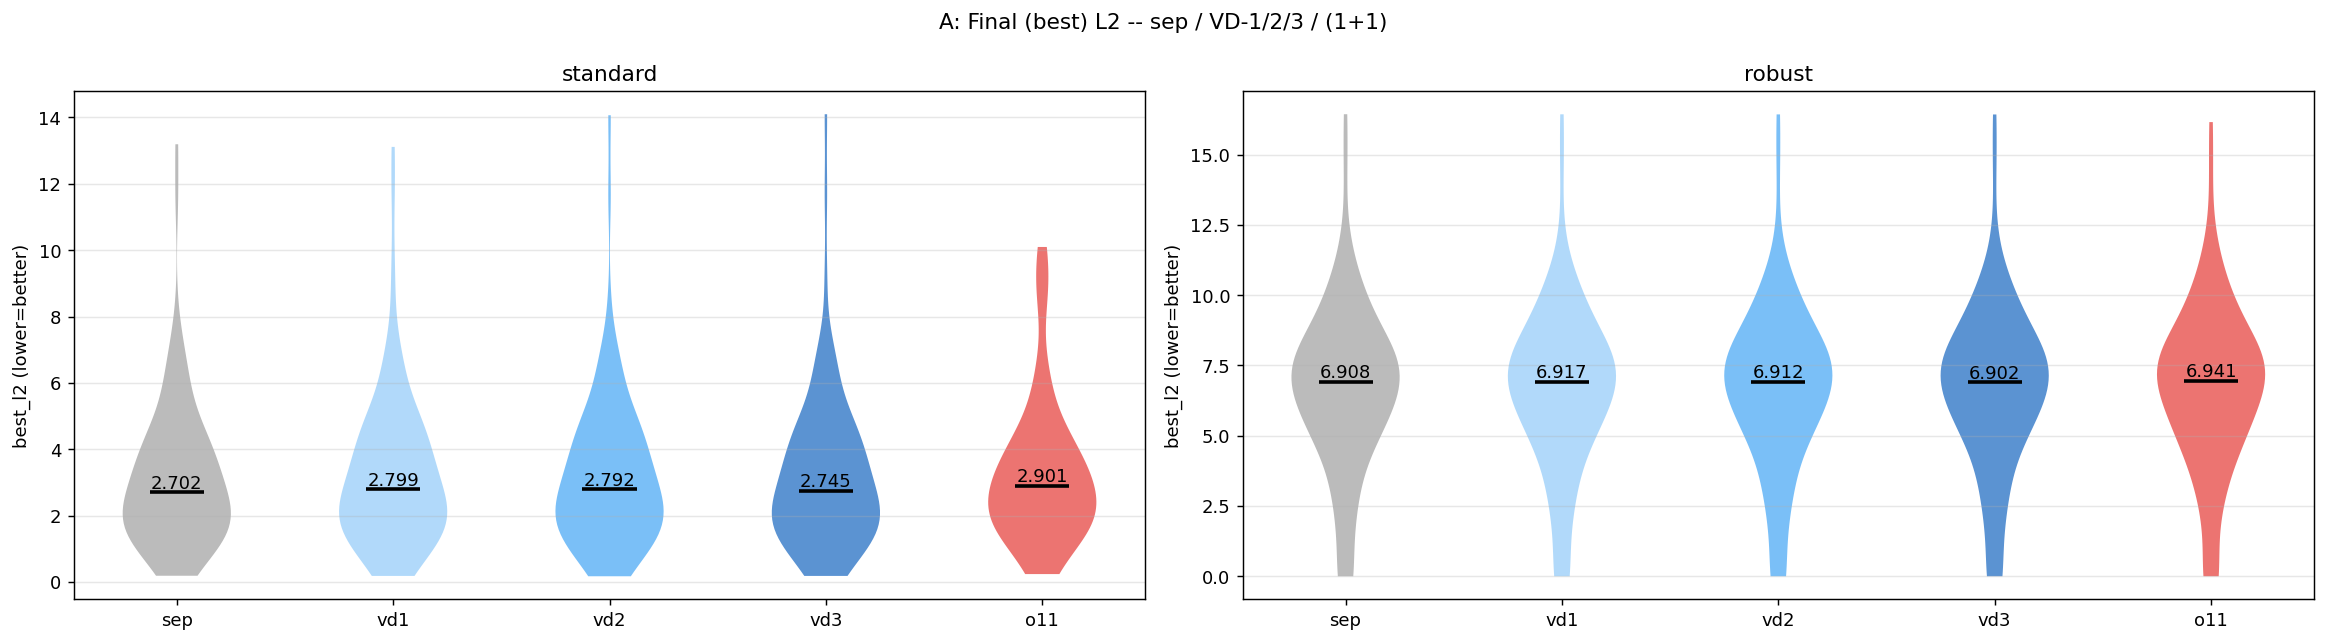

In [3]:
display(Image(f'{OUT}/A_final_l2.png'))

## B: Convergence curves

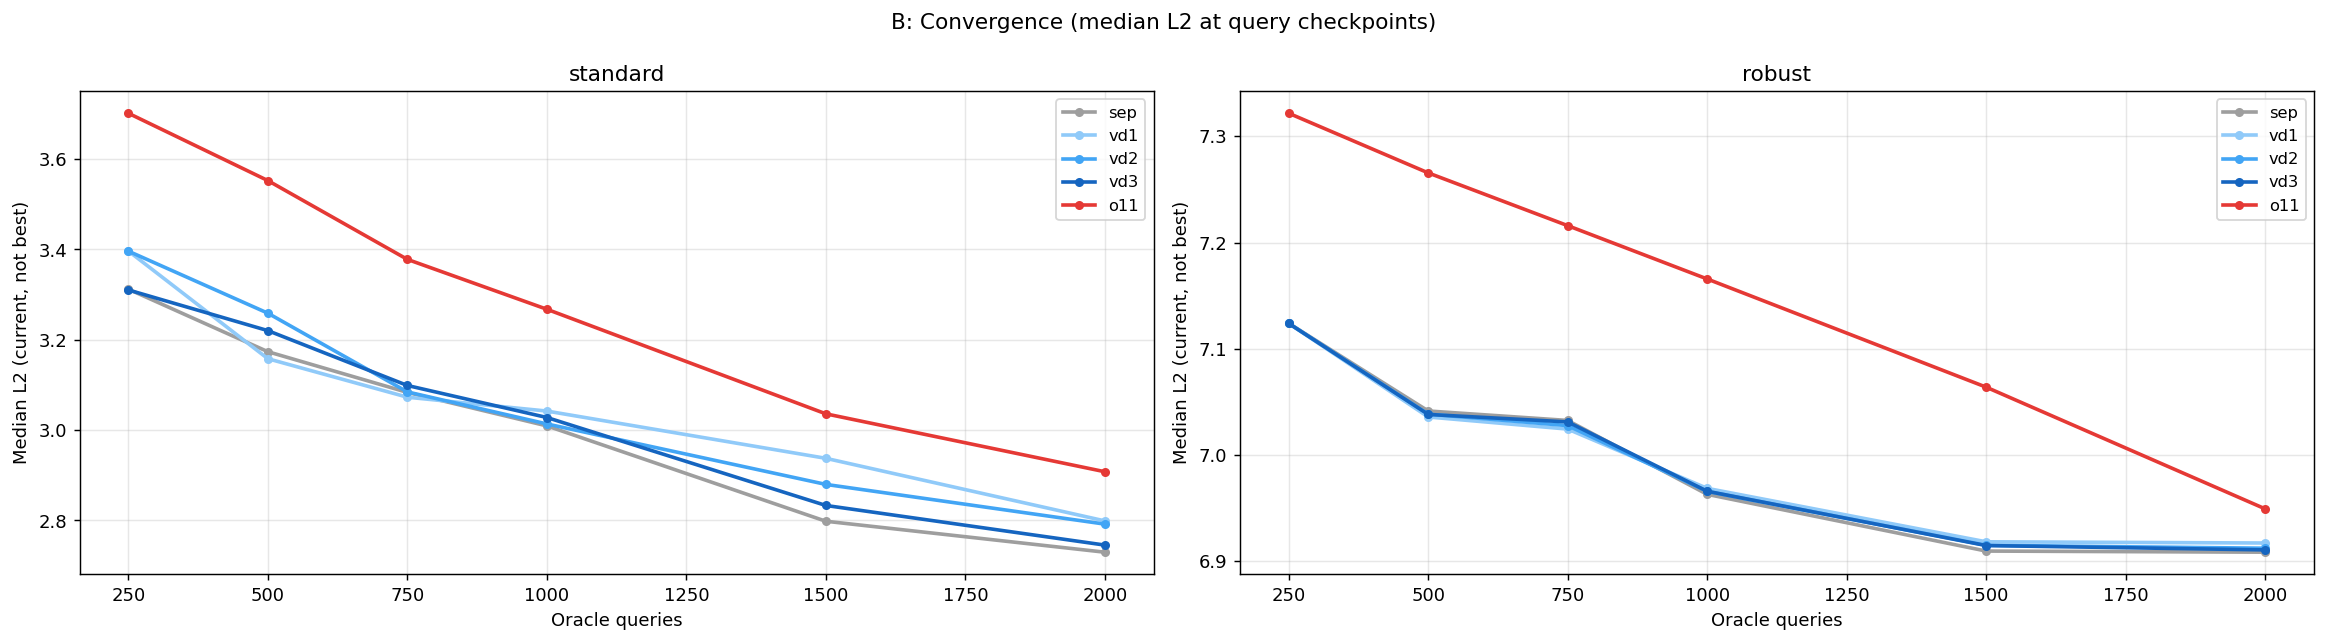

In [4]:
display(Image(f'{OUT}/B_convergence.png'))

## Paired per-image comparison (vs sep)

In [5]:
print('=== PAIRED COMPARISON (per image, best_l2 vs sep) ===')
for cname in ['vd1', 'vd2', 'vd3', 'o11']:
    for mname in MODEL_NAMES:
        base = ok[(ok.condition=='sep')  & (ok.model==mname)].set_index('image_idx')['best_l2']
        oth  = ok[(ok.condition==cname) & (ok.model==mname)].set_index('image_idx')['best_l2']
        common = base.index.intersection(oth.index)
        b, o_ = base.loc[common], oth.loc[common]
        win_rate = float((o_ < b).mean())
        rel_impr = float(np.median((b - o_) / b))
        print(f'{cname:4s} vs sep | {mname:8s}: n={len(common)}  '
              f'{cname}-wins={win_rate*100:5.1f}%  median rel impr={rel_impr*100:+.2f}%')


=== PAIRED COMPARISON (per image, best_l2 vs sep) ===
vd1  vs sep | standard: n=100  vd1-wins= 40.0%  median rel impr=-0.12%
vd1  vs sep | robust  : n=90  vd1-wins= 44.4%  median rel impr=-0.00%
vd2  vs sep | standard: n=100  vd2-wins= 42.0%  median rel impr=-0.16%
vd2  vs sep | robust  : n=90  vd2-wins= 43.3%  median rel impr=-0.01%
vd3  vs sep | standard: n=100  vd3-wins= 40.0%  median rel impr=-0.26%
vd3  vs sep | robust  : n=90  vd3-wins= 40.0%  median rel impr=-0.02%
o11  vs sep | standard: n=100  o11-wins= 36.0%  median rel impr=-6.59%
o11  vs sep | robust  : n=90  o11-wins= 58.9%  median rel impr=+1.36%


- **vd1/vd2/vd3 vs sep**: win rates 40-44% on both models, median relative
  *dis*improvement of 0.0-0.3% -- a small, consistent edge to sep, not a
  few outliers.
- **o11 vs sep, standard**: only 36% win rate, median relative
  disimprovement -6.6% -- a substantial and consistent gap.
- **o11 vs sep, robust**: 58.9% win rate with median relative *improvement*
  +1.4% -- o11 wins on *more* individual images here, yet its median
  best_l2 (6.9411) is slightly *worse* than sep's (6.9084). The two
  rankings disagree because the distribution is skewed: o11 nudges ahead on
  many easy images but loses by a larger margin on a smaller number of hard
  ones, which dominate the median-of-best_l2 comparison less but the
  win-rate comparison more.


## D: Generations, query allocation, improvement ratio

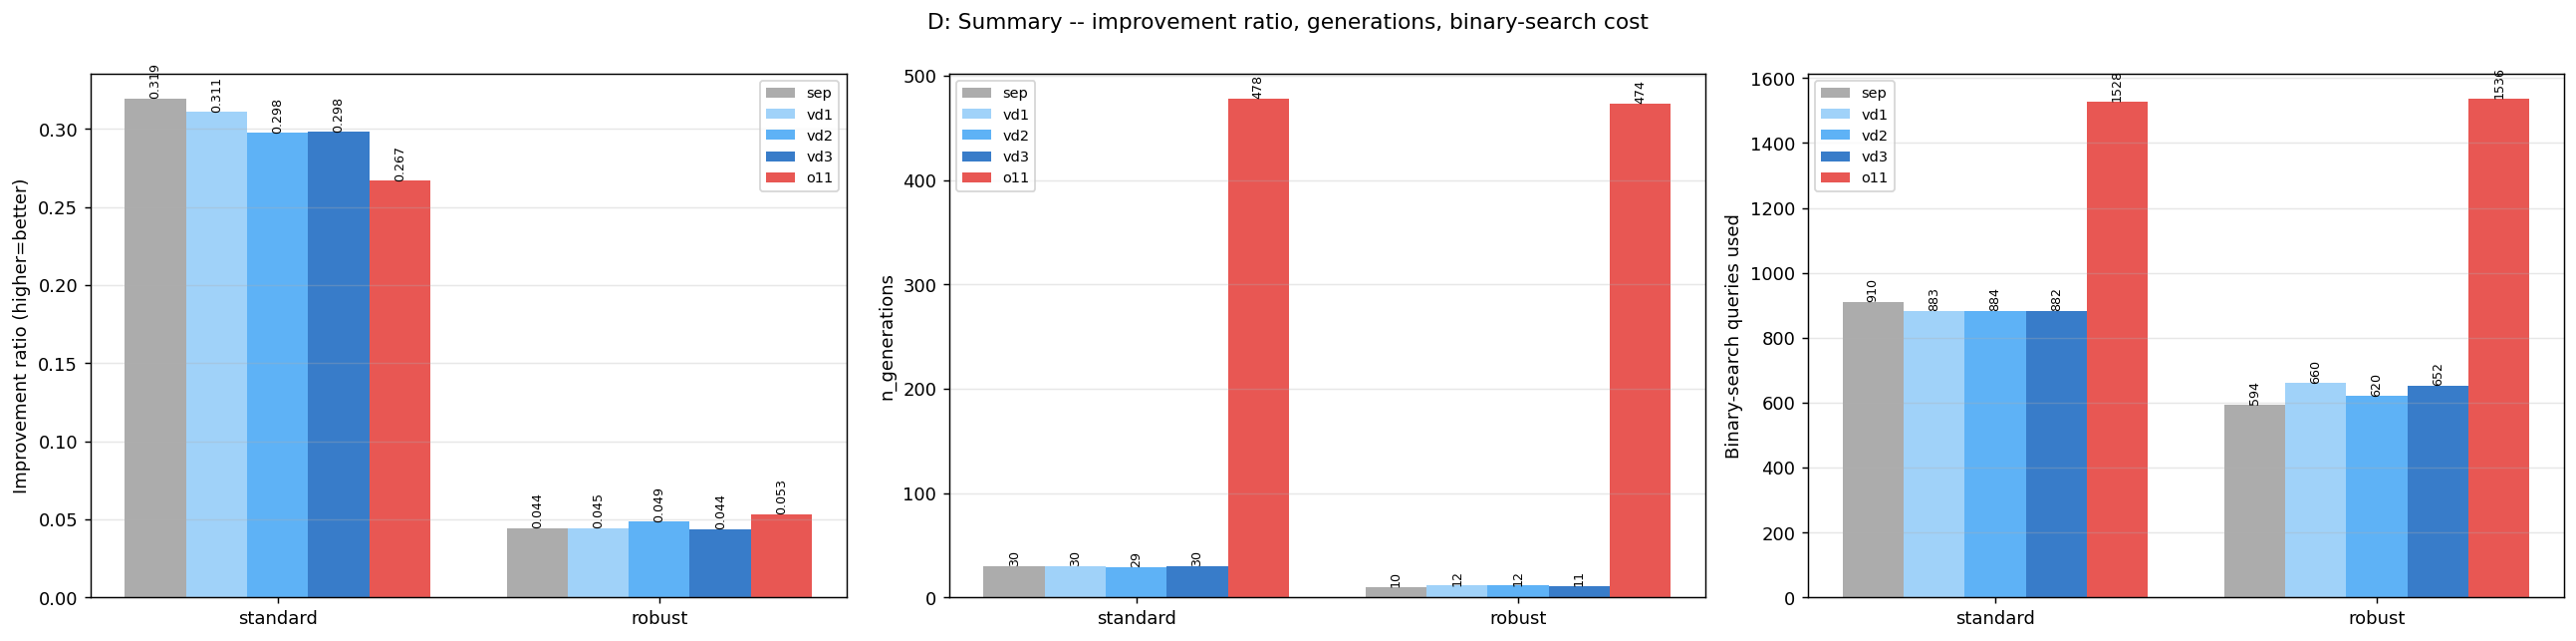

In [6]:
display(Image(f'{OUT}/D_summary.png'))

## F: Effect of VkD rank k

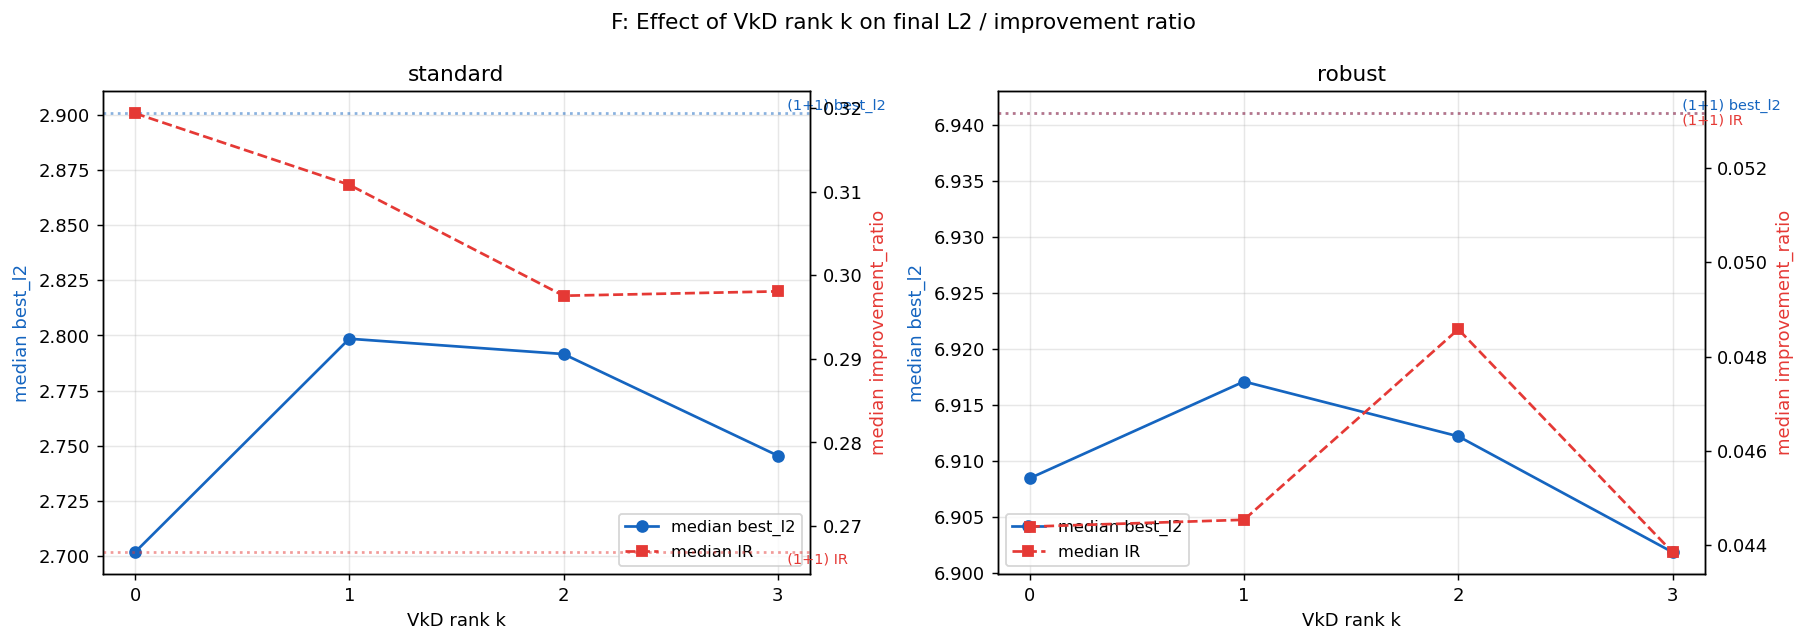

In [7]:
display(Image(f'{OUT}/F_k_sweep.png'))

## G: VkD dominant-direction norms over generations

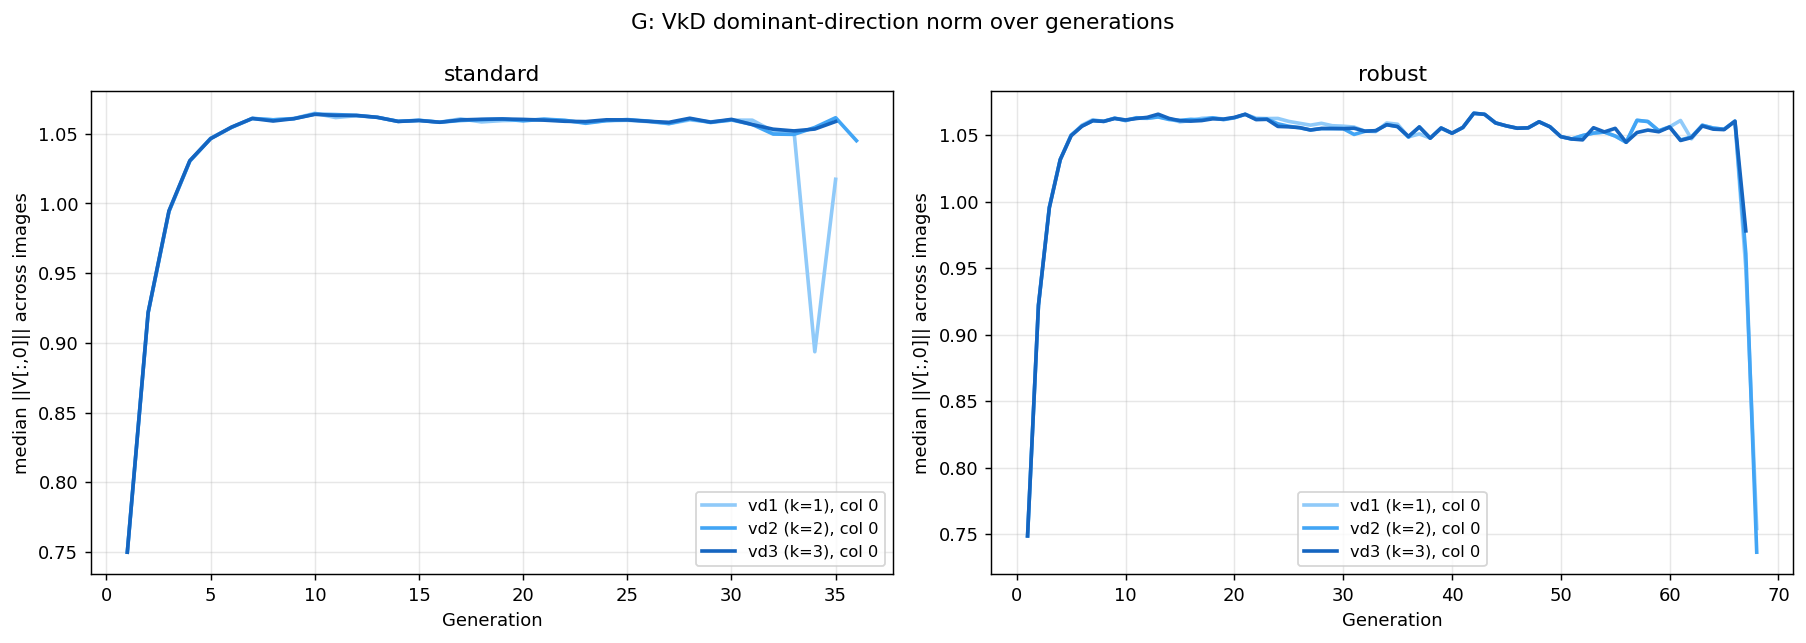

In [8]:
display(Image(f'{OUT}/G_v_norms.png'))

In [9]:
print('=== Median ||V[:,i]|| at final generation, per condition/model ===')
for cname in ['vd1', 'vd2', 'vd3']:
    for mname in MODEL_NAMES:
        finals = [v_norms_store[(cname, mname, i)][-1]
                  for i in range(100)
                  if (cname, mname, i) in v_norms_store and v_norms_store[(cname, mname, i)]]
        if finals:
            arr = np.array(finals)
            meds = np.median(arr, axis=0)
            print(f'{cname} {mname}: n={len(arr)}  median final norms = '
                  + ', '.join(f'{m:.3f}' for m in meds))


=== Median ||V[:,i]|| at final generation, per condition/model ===
vd1 standard: n=100  median final norms = 1.052
vd1 robust: n=90  median final norms = 1.057
vd2 standard: n=100  median final norms = 1.054, 0.798
vd2 robust: n=90  median final norms = 1.057, 0.799
vd3 standard: n=100  median final norms = 1.055, 0.796, 0.639
vd3 robust: n=90  median final norms = 1.055, 0.799, 0.640


The V column norms are remarkably **consistent across k and across models**:
column 0 settles near **~1.05**, column 1 near **~0.80**, column 2 near
**~0.64**, regardless of whether k=1, 2, or 3, and regardless of standard
vs robust model. Adding more columns doesn't change the earlier columns'
magnitudes, and the ordering (col0 > col1 > col2) is the same every time.

This looks like a **stable property of the self-normalised update itself**
rather than evidence of attack-relevant structure in any particular image's
loss landscape -- i.e. V grows to a "typical noise" magnitude set by
`mu`/`mueff` and the eigenvalue-ratio statistics of `Y = zs_ranked * w_eff`
(which are themselves roughly image-independent), not because it has locked
onto a genuinely exploitable direction. This is consistent with the paired
comparison: V grows to a non-trivial size in every run, but doesn't
translate into a systematic win over sep's pure diagonal.


## H: (1+1)-CMA-ES sigma and p_succ adaptation

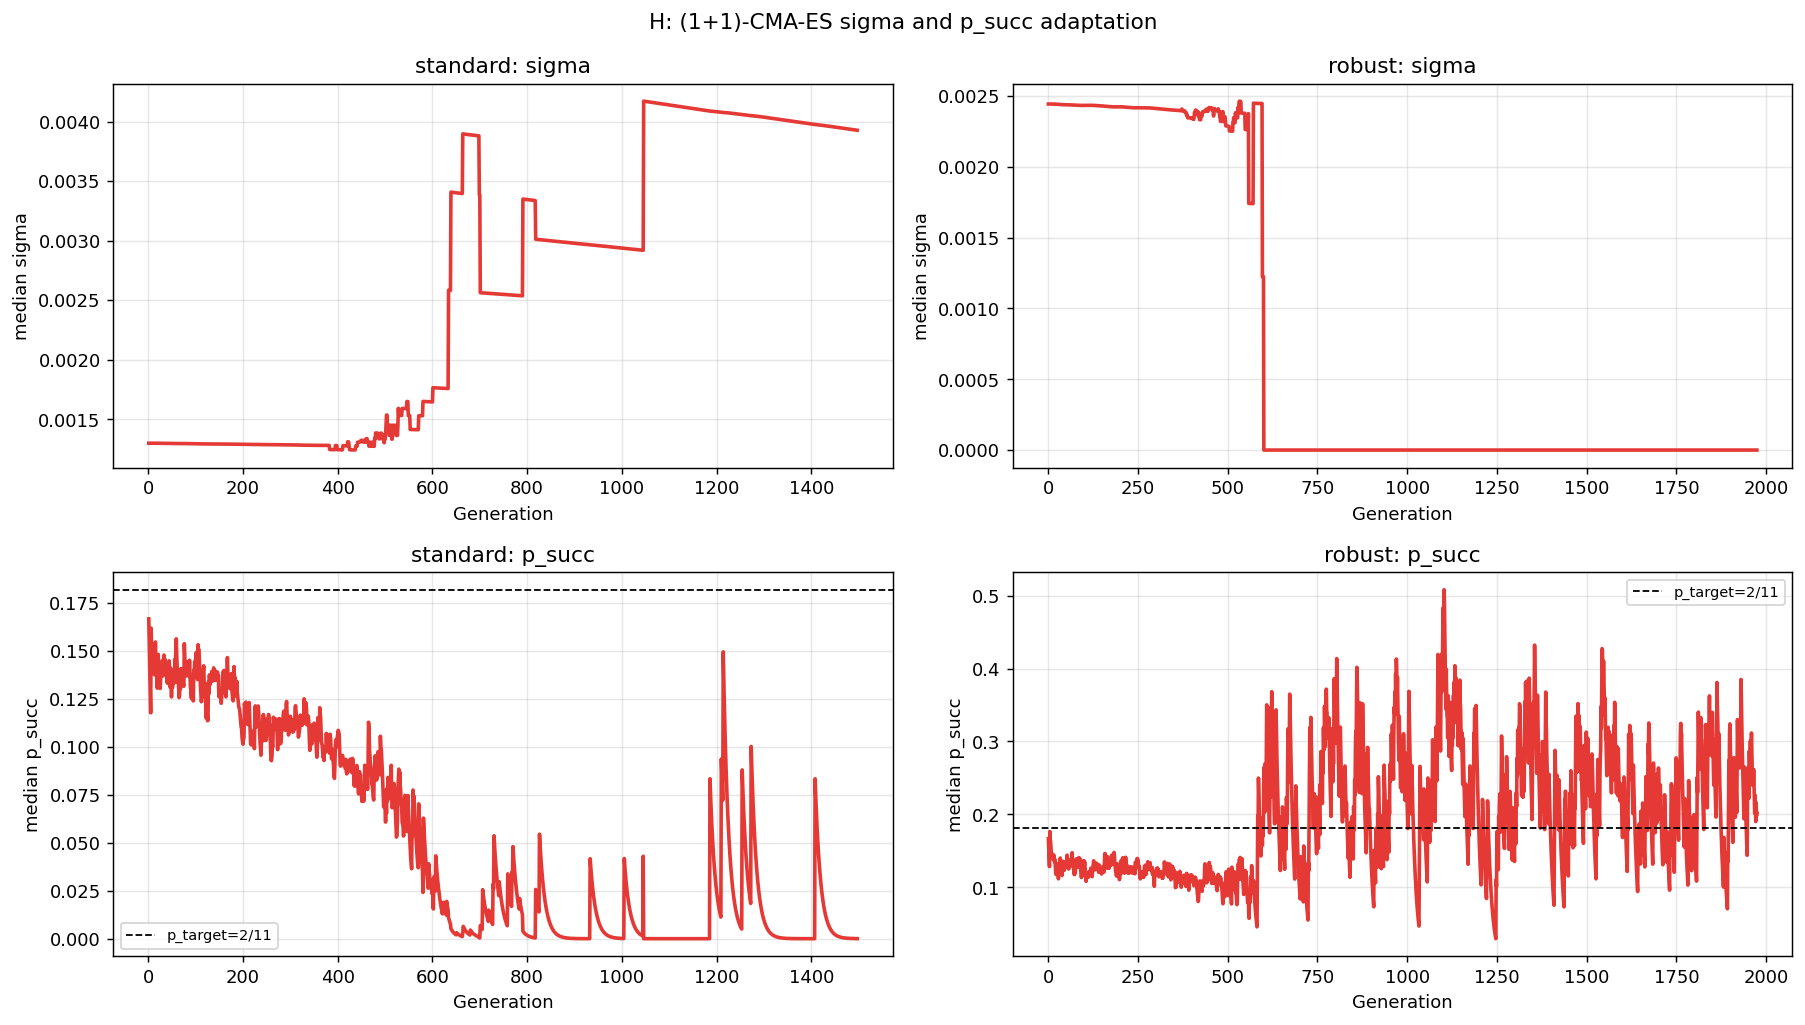

In [10]:
display(Image(f'{OUT}/H_o11_diag.png'))

## Conclusions

1. **sep-CMA-ES (diagonal covariance, k=0) remains the best choice** of the
   five conditions tested, on both models, at the full Q=2000 budget.
2. **VkD's extra rank-k directions (k=1,2,3) consistently cost a small
   amount** (0.0-0.3% median) rather than helping, on the standard model,
   and are noise-level neutral on the robust model. The V matrices grow to
   a consistent ~1.05/0.80/0.64 magnitude pattern in every condition/model,
   suggesting this is an artifact of the (self-normalised) update dynamics
   rather than image-specific structure being captured.
3. **(1+1)-CMA-ES is clearly worse on the standard model** (-6.6% median,
   only 36% win rate vs sep) despite ~16x more generations (478 vs 30).
   On the robust model it's roughly competitive by win-rate (58.9%) but not
   by median best_l2, due to a skewed distribution.
4. **Net recommendation**: keep sep-CMA-ES (`evolba_vkd(vk_rank=0)`, i.e.
   the existing `evolba_tuned`) as the production configuration. Neither
   VkD nor (1+1) justify their added complexity for this attack setting.

## Caveats / possible follow-ups

- The carrier config (`xi_step_scale=0.5, tau=3, ...`) was tuned *for*
  sep-CMA-ES in Stage 1; it's possible VkD or (1+1) would benefit from their
  own hyperparameter tuning (e.g. a different `cv` schedule, or `xi_step_scale`
  for o11). This study answers "does VkD/( 1+1) help as a drop-in
  replacement under sep's tuned settings", not "what is VkD/(1+1)'s ceiling
  under its own best settings".
- `o11`'s sigma adaptation was shown (in validation) to be nearly inert at
  n=3072 (`d_damp ~ 1537`), so its fixed `sigma0 = init_l2/n` choice is
  doing most of the work; a per-image or per-model sigma0 might change the
  picture.
